# 1. Configuration and Imports

In [ ]:
import librosa
import numpy as np
from pathlib import Path
from typing import Union
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple

# 2. Feature Extraction Function Definitions

In [ ]:

def extract_features(file_path: Union[str, Path], n_mfcc=13) -> np.ndarray:
    """Calculates the mean and standard deviation of MFCC coefficients
      to capture spectral characteristics and temporal dynamics of the audio segment.
    """

    y, sr = librosa.load(str(file_path), sr=16000)
    # Calculate MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std = np.std(mfcc.T, axis=0)
    
    return np.hstack([mfcc_mean, mfcc_std])

def load_dataset(processed_path: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray, dict]:
    """
    Crawls the processed data directory to extract features from all samples
      while automatically generating a numeric label mapping based on folder names.
    """
    X, y = [], []
    label_to_name = {}
    processed_dir = Path(processed_path)
    
    for category_dir in processed_dir.iterdir():
        if not category_dir.is_dir():
            continue

        try:        
            label = int(category_dir.name.split('_')[0])
            clean_name = category_dir.name.split('_', 1)[1].replace('_', ' ').title()
            label_to_name[label] = clean_name
        except (ValueError, IndexError):
            continue

        for file_path in category_dir.glob("*.wav"):
            features = extract_features(file_path=file_path)
            X.append(features)
            y.append(label)

    return np.array(X), np.array(y), label_to_name

# 3. Preparing the Data Set

In [ ]:
X, y, target_map = load_dataset('../data/processed')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Number of samples in X: {len(X)}")
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Unique labels in y: {np.unique(y)}")

c:\Users\emill\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of samples in X: 27079
Training set size: (21663, 13)
Test set size: (5416, 13)
Unique labels in y: [0 1 2 3]


# 4. Training a Random Forest Model

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=7)
model.fit(X=X_train,y=y_train)

y_pred = model.predict(X=X_test)
target_names = [target_map[i] for i in sorted(target_map.keys())]

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 93.15%
                precision    recall  f1-score   support

       Ambient       0.99      0.86      0.92       658
False Positive       1.00      0.44      0.61        89
        Speech       0.93      0.94      0.94      2130
      Violence       0.92      0.96      0.94      2539

      accuracy                           0.93      5416
     macro avg       0.96      0.80      0.85      5416
  weighted avg       0.93      0.93      0.93      5416



# 5. Confusion Matrix Chart

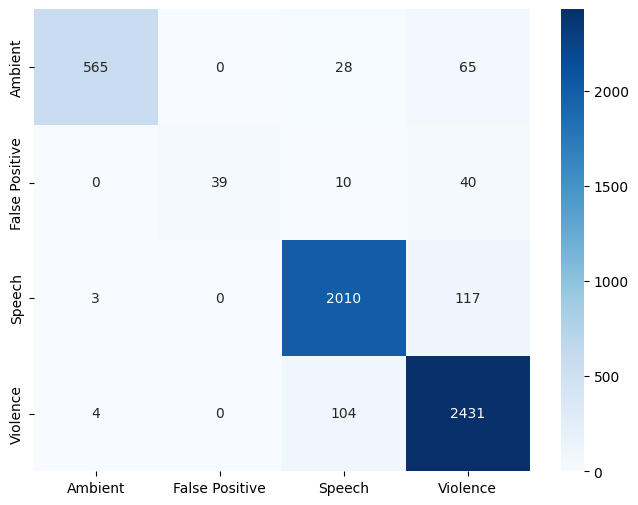

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.show()

# 6. Model Serialization

In [ ]:
import joblib

model_dir = Path('../models')
model_dir.mkdir(parents=True, exist_ok=True)
# Save model 
joblib.dump(model, model_dir / 'rf_v1.pkl')

# Save name map
joblib.dump(target_map, model_dir / 'target_map.pkl')